In [1]:
import os
import csv
import time
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from datasets import load_dataset, Dataset
from transformers import (
    RobertaTokenizer,
    RobertaForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    TrainerCallback
)

from sklearn.metrics import f1_score,classification_report
from scipy.stats import pearsonr


In [2]:
SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)


In [3]:

print("\nLoading BRIGHTER dataset from Hugging Face...")

train_data = load_dataset("brighter-dataset/BRIGHTER-emotion-intensities", "eng", split="train")
val_data   = load_dataset("brighter-dataset/BRIGHTER-emotion-intensities", "eng", split="dev")
test_data  = load_dataset("brighter-dataset/BRIGHTER-emotion-intensities", "eng", split="test")

train_df = train_data.to_pandas()
val_df   = val_data.to_pandas()
test_df  = test_data.to_pandas()

print("\nOriginal split sizes:")
print("Train:", len(train_df))
print("Dev  :", len(val_df))
print("Test :", len(test_df))

print("\nSample data:")
print(train_df.head())



Loading BRIGHTER dataset from Hugging Face...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

eng/train-00000-of-00001.parquet:   0%|          | 0.00/179k [00:00<?, ?B/s]

eng/dev-00000-of-00001.parquet:   0%|          | 0.00/11.8k [00:00<?, ?B/s]

eng/test-00000-of-00001.parquet:   0%|          | 0.00/182k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2763 [00:00<?, ? examples/s]

Generating dev split:   0%|          | 0/115 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2765 [00:00<?, ? examples/s]


Original split sizes:
Train: 2763
Dev  : 115
Test : 2765

Sample data:
                        id                                               text  \
0  eng_train_track_b_00001                       Colorado, middle of nowhere.   
1  eng_train_track_b_00002  This involved swimming a pretty large lake tha...   
2  eng_train_track_b_00003        It was one of my most shameful experiences.   
3  eng_train_track_b_00004  After all, I had vegetables coming out my ears...   
4  eng_train_track_b_00005                        Then the screaming started.   

   anger  disgust  fear  joy  sadness  surprise  
0      0      NaN     1    0        0         1  
1      0      NaN     2    0        0         0  
2      0      NaN     1    0        3         0  
3      0      NaN     0    0        0         0  
4      0      NaN     3    0        1         2  


In [4]:
EMOTIONS = ["anger", "fear", "joy", "sadness", "surprise"]
LEVELS = [1, 2, 3]
LABELS = [f"{emotion}_{level}" for emotion in EMOTIONS for level in LEVELS]
NUM_LABELS = len(LABELS)

print("Labels:")
print(LABELS)
print("Number of labels:", NUM_LABELS)
def convert_single_step_labels(df):
    df = df.copy()

    # Remove disgust
    if "disgust" in df.columns:
        df = df.drop(columns=["disgust"])

    # Create 15 binary labels
    for emotion in EMOTIONS:
        df[f"{emotion}_1"] = (df[emotion] == 1).astype(int)
        df[f"{emotion}_2"] = (df[emotion] == 2).astype(int)
        df[f"{emotion}_3"] = (df[emotion] == 3).astype(int)

    return df

train_single = convert_single_step_labels(train_df)
val_single   = convert_single_step_labels(val_df)
test_single  = convert_single_step_labels(test_df)

print("\nSingle-step sample:")
print(train_single[["text"] + LABELS].head())


Labels:
['anger_1', 'anger_2', 'anger_3', 'fear_1', 'fear_2', 'fear_3', 'joy_1', 'joy_2', 'joy_3', 'sadness_1', 'sadness_2', 'sadness_3', 'surprise_1', 'surprise_2', 'surprise_3']
Number of labels: 15

Single-step sample:
                                                text  anger_1  anger_2  \
0                       Colorado, middle of nowhere.        0        0   
1  This involved swimming a pretty large lake tha...        0        0   
2        It was one of my most shameful experiences.        0        0   
3  After all, I had vegetables coming out my ears...        0        0   
4                        Then the screaming started.        0        0   

   anger_3  fear_1  fear_2  fear_3  joy_1  joy_2  joy_3  sadness_1  sadness_2  \
0        0       1       0       0      0      0      0          0          0   
1        0       0       1       0      0      0      0          0          0   
2        0       1       0       0      0      0      0          0          0   
3        

In [5]:
full_df = pd.concat([train_single, val_single, test_single], ignore_index=True)
full_df = full_df[["text"] + LABELS]
full_df = full_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

n = len(full_df)
train_end = int(0.7 * n)
val_end = int(0.9 * n)

train_single = full_df[:train_end]
val_single = full_df[train_end:val_end]
test_single = full_df[val_end:]

print({
    "train": len(train_single),
    "val": len(val_single),
    "test": len(test_single)
})

# Convert pandas DataFrames to Hugging Face Dataset


{'train': 3950, 'val': 1128, 'test': 565}


In [6]:
# Convert pandas DataFrames to Hugging Face Dataset
train_single = Dataset.from_pandas(train_single, preserve_index=False)
val_single   = Dataset.from_pandas(val_single, preserve_index=False)
test_single  = Dataset.from_pandas(test_single, preserve_index=False)
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=128
    )

train_single = train_single.map(tokenize_function)
val_single   = val_single.map(tokenize_function)
test_single  = test_single.map(tokenize_function)



tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/3950 [00:00<?, ? examples/s]

Map:   0%|          | 0/1128 [00:00<?, ? examples/s]

Map:   0%|          | 0/565 [00:00<?, ? examples/s]

In [7]:
def add_labels(example):
    example["labels"] = [float(example[label]) for label in LABELS]
    return example

train_single = train_single.map(add_labels)
val_single   = val_single.map(add_labels)
test_single  = test_single.map(add_labels)

train_single.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
val_single.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
test_single.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])



Map:   0%|          | 0/3950 [00:00<?, ? examples/s]

Map:   0%|          | 0/1128 [00:00<?, ? examples/s]

Map:   0%|          | 0/565 [00:00<?, ? examples/s]

In [8]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    probs = 1 / (1 + np.exp(-logits))
    preds = (probs >= 0.5).astype(int)

    f1_macro = f1_score(labels, preds, average="macro", zero_division=0)
    f1_micro = f1_score(labels, preds, average="micro", zero_division=0)

    pearsons = []
    for i in range(labels.shape[1]):
        if np.std(labels[:, i]) == 0 or np.std(probs[:, i]) == 0:
            pearsons.append(0.0)
        else:
            p, _ = pearsonr(labels[:, i], probs[:, i])
            pearsons.append(0.0 if np.isnan(p) else float(p))

    pearson_mean = float(np.mean(pearsons))

    return {
        "f1_macro": f1_macro,
        "f1_micro": f1_micro,
        "pearson_mean": pearson_mean
    }

Mounted at /content/drive


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


Total training time: 911.0 seconds
Log file saved at: /content/drive/MyDrive/RoBERTa_SingleStep_log.csv



Final Test Results:
test_loss: 0.2662332355976105
test_f1_macro: 0.38191358881683063
test_f1_micro: 0.45375
test_pearson_mean: 0.4294302592674891
test_runtime: 2.5753
test_samples_per_second: 219.394
test_steps_per_second: 55.14
epoch: 10.0

Class-wise results appended once at the end of the same file.


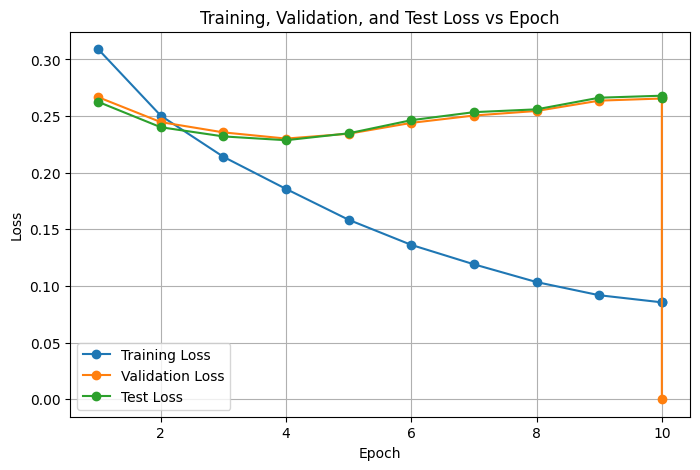

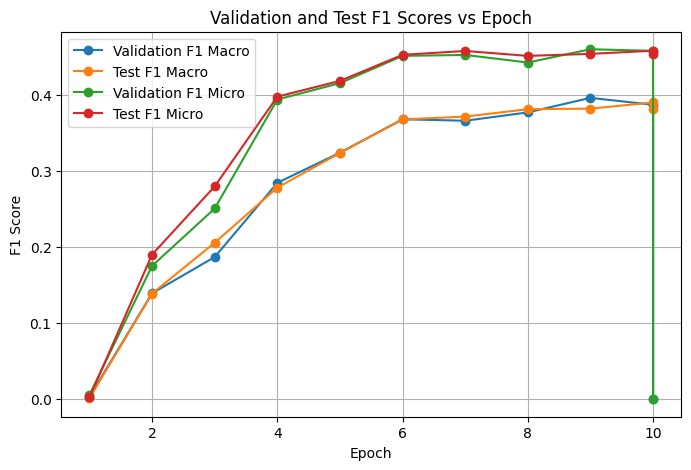

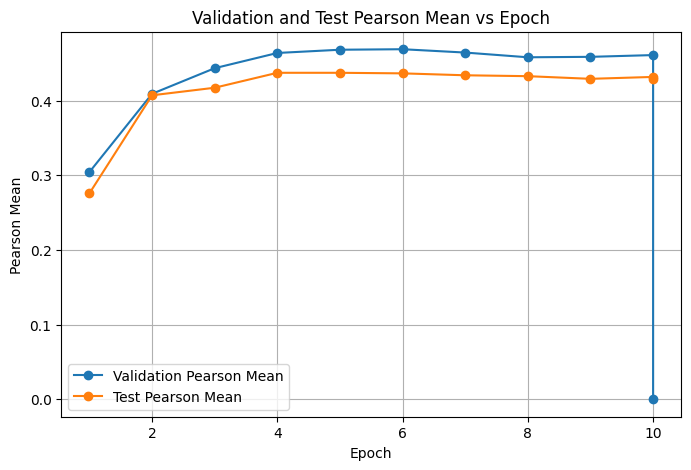

In [9]:
# =========================================================
# 11. GOOGLE DRIVE + LOG FILE
# =========================================================
from google.colab import drive
drive.mount('/content/drive')

LOG_FILE = "/content/drive/MyDrive/RoBERTa_SingleStep_log.csv"
os.makedirs("/content/drive/MyDrive", exist_ok=True)

with open(LOG_FILE, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow([
        "epoch",
        "train_loss",
        "val_loss",
        "test_loss",
        "val_f1_macro",
        "test_f1_macro",
        "val_f1_micro",
        "test_f1_micro",
        "val_pearson_mean",
        "test_pearson_mean"
    ])


# =========================================================
# 12. LISTS FOR PLOTTING
# =========================================================
epoch_list = []

train_loss_list = []

val_loss_list = []
val_f1_macro_list = []
val_f1_micro_list = []
val_pearson_mean_list = []

test_loss_list = []
test_f1_macro_list = []
test_f1_micro_list = []
test_pearson_mean_list = []


# =========================================================
# 13. CALLBACK
#     one row per epoch:
#     train_loss, val_loss, test_loss, val/test scores
# =========================================================
class SaveMetricsCallback(TrainerCallback):
    def __init__(self, file_path, test_dataset):
        self.file_path = file_path
        self.test_dataset = test_dataset
        self.current_train_loss = None
        self.trainer_ref = None
        self._inside_test_eval = False

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is not None and "loss" in logs and "eval_loss" not in logs:
            self.current_train_loss = float(logs["loss"])

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if metrics is None:
            return

        if self._inside_test_eval:
            return

        epoch = float(metrics.get("epoch", state.epoch))
        train_loss = self.current_train_loss if self.current_train_loss is not None else ""

        val_loss = float(metrics.get("eval_loss", 0.0))
        val_f1_macro = float(metrics.get("eval_f1_macro", 0.0))
        val_f1_micro = float(metrics.get("eval_f1_micro", 0.0))
        val_pearson_mean = float(metrics.get("eval_pearson_mean", 0.0))

        test_loss = ""
        test_f1_macro = ""
        test_f1_micro = ""
        test_pearson_mean = ""

        if self.trainer_ref is not None:
            self._inside_test_eval = True
            test_results = self.trainer_ref.evaluate(
                eval_dataset=self.test_dataset,
                metric_key_prefix="test"
            )
            self._inside_test_eval = False

            test_loss = float(test_results.get("test_loss", 0.0))
            test_f1_macro = float(test_results.get("test_f1_macro", 0.0))
            test_f1_micro = float(test_results.get("test_f1_micro", 0.0))
            test_pearson_mean = float(test_results.get("test_pearson_mean", 0.0))

            test_loss_list.append(test_loss)
            test_f1_macro_list.append(test_f1_macro)
            test_f1_micro_list.append(test_f1_micro)
            test_pearson_mean_list.append(test_pearson_mean)

        epoch_list.append(epoch)
        train_loss_list.append(train_loss)

        val_loss_list.append(val_loss)
        val_f1_macro_list.append(val_f1_macro)
        val_f1_micro_list.append(val_f1_micro)
        val_pearson_mean_list.append(val_pearson_mean)

        with open(self.file_path, "a", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            writer.writerow([
                epoch,
                train_loss,
                val_loss,
                test_loss,
                val_f1_macro,
                test_f1_macro,
                val_f1_micro,
                test_f1_micro,
                val_pearson_mean,
                test_pearson_mean
            ])


# =========================================================
# 14. MODEL
# =========================================================
model = RobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=NUM_LABELS,
    problem_type="multi_label_classification"
)


# =========================================================
# 15. TRAINING ARGUMENTS
# =========================================================
training_args = TrainingArguments(
    output_dir="/content/roberta_output",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=4,
    num_train_epochs=10,
    eval_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=SEED
)


# =========================================================
# 16. TRAINER
# =========================================================
callback = SaveMetricsCallback(LOG_FILE, test_single)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_single,
    eval_dataset=val_single,
    data_collator=data_collator,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[callback]
)

callback.trainer_ref = trainer


# =========================================================
# 17. TRAIN
# =========================================================
start = time.time()
trainer.train()
end = time.time()

print(f"\nTotal training time: {end - start:.1f} seconds")
print("Log file saved at:", LOG_FILE)


# =========================================================
# 18. FINAL TEST RESULTS
# =========================================================
final_test_results = trainer.evaluate(
    eval_dataset=test_single,
    metric_key_prefix="test"
)

print("\nFinal Test Results:")
for key, value in final_test_results.items():
    print(f"{key}: {value}")


# =========================================================
# 19. CLASS-WISE RESULTS ONLY ONCE AT THE END
# =========================================================
pred = trainer.predict(test_single)

logits = pred.predictions
labels = pred.label_ids

probs = 1 / (1 + np.exp(-logits))
preds = (probs >= 0.5).astype(int)

report_dict = classification_report(
    labels,
    preds,
    target_names=LABELS,
    zero_division=0,
    output_dict=True
)

with open(LOG_FILE, "a", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)

    writer.writerow([])
    writer.writerow(["CLASSWISE RESULTS"])
    writer.writerow(["class", "precision", "recall", "f1_score", "support"])

    for class_name in LABELS:
        row = report_dict.get(class_name, {})
        writer.writerow([
            class_name,
            row.get("precision", ""),
            row.get("recall", ""),
            row.get("f1-score", ""),
            row.get("support", "")
        ])

print("\nClass-wise results appended once at the end of the same file.")


# =========================================================
# 20. PLOTS
# =========================================================

# all losses in one graph
plt.figure(figsize=(8, 5))
plt.plot(epoch_list, train_loss_list, marker="o", label="Training Loss")
plt.plot(epoch_list, val_loss_list, marker="o", label="Validation Loss")
plt.plot(epoch_list[:len(test_loss_list)], test_loss_list, marker="o", label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training, Validation, and Test Loss vs Epoch")
plt.legend()
plt.grid(True)
plt.show()

# F1 scores in one graph
plt.figure(figsize=(8, 5))
plt.plot(epoch_list, val_f1_macro_list, marker="o", label="Validation F1 Macro")
plt.plot(epoch_list[:len(test_f1_macro_list)], test_f1_macro_list, marker="o", label="Test F1 Macro")
plt.plot(epoch_list, val_f1_micro_list, marker="o", label="Validation F1 Micro")
plt.plot(epoch_list[:len(test_f1_micro_list)], test_f1_micro_list, marker="o", label="Test F1 Micro")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("Validation and Test F1 Scores vs Epoch")
plt.legend()
plt.grid(True)
plt.show()

# Pearson in one graph
plt.figure(figsize=(8, 5))
plt.plot(epoch_list, val_pearson_mean_list, marker="o", label="Validation Pearson Mean")
plt.plot(epoch_list[:len(test_pearson_mean_list)], test_pearson_mean_list, marker="o", label="Test Pearson Mean")
plt.xlabel("Epoch")
plt.ylabel("Pearson Mean")
plt.title("Validation and Test Pearson Mean vs Epoch")
plt.legend()
plt.grid(True)
plt.show()